In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=sns.load_dataset("tips")#loading library from seaborn
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<function matplotlib.pyplot.show(close=None, block=None)>

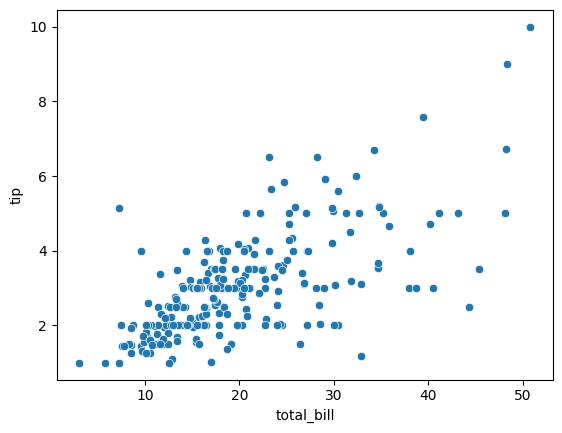

In [3]:
sns.scatterplot(x='total_bill',y='tip',data=df) 
plt.show

In [4]:
df=pd.get_dummies(df,drop_first=True)
X=df.drop("tip",axis=1) # sklearn expect 2 D array 
y=df['tip']

In [5]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [10]:
y_pred=model.predict(x_test)
from sklearn.metrics import mean_squared_error,r2_score

In [11]:
print("MSE : ",mean_squared_error(y_test,y_pred))
print("r2 score : ",r2_score(y_test,y_pred)) 

MSE :  1.4327710344102564
r2 score :  0.29479461333647317


In [16]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("CV R² scores:", scores)
print("Mean R²:", scores.mean())

CV R² scores: [0.37718272 0.5228954  0.50207102 0.20739829 0.36361826]
Mean R²: 0.39463313765137004
